# **Projeto com AWS: O Peso das Palavras - Análise Exploratória**
**Banco de Dados**: *Avaliações de Clientes*

**Fonte**: *AWS - Banco oficial disponibilizado para o projeto na faculdade SENAI Suiço-Brasileiro!*


# **Problema de Negócio**

Em marketplaces digitais, clientes avaliam produtos por meio de notas (1 a 5) e comentários textuais.
No entanto, nem sempre a nota atribuída é coerente com o conteúdo do comentário, o que pode dificultar
a interpretação real da satisfação do cliente.
Diante disso, surge a necessidade de analisar a relação entre as avaliações numéricas e os comentários,
buscando identificar padrões de comportamento e possíveis inconsistência

# **Objetivo**

O principal desafio será investigar os dados de avaliações de clientes, buscando compreender a relação entre os comentários textuais e as notas atribuídas, identificando padrões,
tendências e possíveis inconsistências na percepção de satisfação.

# **Descrição do Banco de Dados**

O conjunto de dados fornecido pela AWS em parceria com o SENAI Suiço-Brasileiro possui 9 tabelas, que são:
- vendedores.csv
- produtos.csv
- pedidos.csv
- pagamentos.csv
- itens_pedidos.csv
- geolocalizacao.csv
- clientes.csv
- avaliacoes.csv
- tabela_auxiliar.csv -> É uma tabela com a tradução de termos que aparecem no Dataset!


# **Linguagens Utilizadas**

**Python**: Principal linguagem de programação utilizada para realizar a análise, varredura e limpeza de um banco de dados. Além das representações gráficas para futura utilização das informações adquiridas no final do processo!

**SQL**: Linguagem utilizada para consulta, criação de filtros e relatórios relacionados a um banco de dados de forma eficiente e eficaz!

# **Bibliotecas Utilizadas**

**Pandas**: Utilizada para a manipulação e entendimento dos dados de uma tabela

**Matplotlib**: Utilizada para gerar gráficos expressando resultados de forma eficiente e intuitiva

**Seaborn**: Assim como a biblioteca matplotlib, também é eficiente para gerar gráficos de qualidade

**Numpy**: Bem utilizada para uma análise estatística precisa e operações matemáticas  

**WordCloud**: Geração de nuvens de palavras para visualizar os termos mais frequentes em comentários e textos

**Counter**: Contagem rápida da frequência de elementos em listas, palavras ou textos

**Warnings**: Controle e ocultação de mensagens de aviso (warnings) durante a execução do código.

# **Instalação das Principais Bibliotecas**

In [2]:
# %pip install pandas numpy matplotlib seaborn wordcloud scikit-learn plotly

# **Modelos de Análise de Sentimento**

**Vader**: (Valence Aware Dictionary and sEntiment Reasoner) é uma ferramenta de Processamento de Linguagem Natural (PLN) baseada em léxico, amplamente utilizada para classificar o sentimento de textos (positivo, negativo ou neutro). Ela é especialmente eficiente para analisar gírias e emojis comuns em mídias sociais.


**leIA**: (Léxico para Inferência Adaptada) é um fork do léxico e uma ferramenta para análise de sentimentos.


**Transformers**: Desenvolvida pela Hugging Face, é o padrão da indústria para trabalhar com modelos de Inteligência Artificial de última geração, como GPT, BERT e LLaMA. Ela fornece ferramentas simples para processamento de linguagem natural, visão computacional e áudio.

## **Instalação dos Modelos**

In [3]:
# %pip install vaderSentiment

In [4]:
# %pip install leia-br

In [5]:
# %pip install transformers

# **Importando Bibliotecas**

In [6]:
from wordcloud import WordCloud
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# **Carregamento do Banco de Dados**

In [7]:
df_avaliacoes = pd.read_csv('tabelas/avaliacoes.csv')
df_vendedores = pd.read_csv('tabelas/vendedores.csv')
df_produtos = pd.read_csv('tabelas/produtos.csv')
df_pedidos = pd.read_csv('tabelas/pedidos.csv')
df_itens_pedidos = pd.read_csv('tabelas/itens_pedidos.csv')
df_geolocalizacao = pd.read_csv('tabelas/geolocalizacao.csv')
df_clientes = pd.read_csv('tabelas/clientes.csv')
df_pagamentos = pd.read_csv('tabelas/pagamentos.csv')

# **Entendendo as Tabelas**
- Visualização Inicial
- Estatísticas Descritivas
- Variáveis
- Linhas Duplicadas
- Linhas Vazias

## **Visualização Inicial**

### **Funções de Análise Exploratória**

In [8]:
def analise_inicial(df):
  print("\nInformações Gerais da Tabela")
  print(df.info())

  print("\nTipo das variáveis")
  display(df.dtypes)

  print("\nPrimeiras 10 Linhas")
  display(df.head(10))

  print("\nUltimas 10 Linhas")
  display(df.tail(10))

  print("\nEstatísticas Descritivas")
  display(df.describe())

  print("\nObservação das Colunas")
  print(df.columns)

  print("\nQuantidade de Linhas e Colunas")
  print(df.shape)
  print()

Ao chamar a função e aplicar a qualquer DataFrame, é possível entender as principais informações dele, como:
- Informações gerais
- Tipo das variavéis
- Estatísticas Descritivas
- Observação das colunas
- Quantidade de linhas
- Quantidade de colunas
- Primeiras linhas da tabela
- Últimas linhas das tabelas

In [9]:
def verificacao(df):
  print("Verificação de Números Nulos")
  print(df.isnull().sum())

  print("\nVerificação de Duplicatas")
  print(f"{df.duplicated().sum()}\n")

Função para verificar informações relevantes antes do tratamento dos dados:
- Verificação de nulos
- Verificação de duplicatas

In [10]:
def exploracao_do_banco(df):
  analise_inicial(df)
  verificacao(df)

Função utilizada para aplicar outras funções de exploração, análise e verificação de uma vez!

In [11]:
def dicionario_dados(df):
    return pd.DataFrame({
        'Coluna': df.columns,
        'Tipo': df.dtypes.values,
        'Valores Nulos': df.isnull().sum().values,
        'Duplicados': df.duplicated().sum()
    })

Função para analisar verificação de duplicatas, nulos, colunas e tipos das colunas/variavéis

In [12]:
def classificacao_sentimento(valor):
  if valor < -0.6:
    return 'Muito negativo'
  elif valor >= -0.6 and valor < -0.2:
    return 'Negativo'
  elif valor >= -0.2 and valor < 0.2:
    return 'Neutro'
  elif valor >= 0.2 and valor <= 0.6:
    return 'Positivo'
  elif valor > 0.6:
    return 'Muito Positivo'
  else:
    return 'Default'

Função utilizada para converter uma coluna de pontuação em uma classificação de sentimento e armazenar, em seguida, transformar em uma nova coluna, com a classificação dos sentimentos

In [13]:
lista = [df_avaliacoes, df_vendedores, df_produtos, df_pedidos, df_itens_pedidos, df_geolocalizacao, df_clientes, df_pagamentos]

# **Exploração do Banco de Dados**

- For utilizado para rodar todas as tabelas de uma vez, permitindo a análise completa das informações delas

In [14]:
for i in range(len(lista)):
    exploracao_do_banco(lista[i])


Informações Gerais da Tabela
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB
None

Tipo das variáveis


review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object


Primeiras 10 Linhas


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17 00:00:00,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47



Ultimas 10 Linhas


...


Ultimas 10 Linhas


,order_id,payment_sequential,payment_type,payment_installments,payment_value
103876,0872d0faafe0cb56e6f2c594cca1522c,1,credit_card,2,127.92
103877,3531718b24dfd5022fb0d101e10e33b9,1,credit_card,1,194.11
103878,2e3d96522c8c378d4135c12a65c977aa,1,credit_card,4,47.62
103879,c45067032fd84f4cf408730ff5205568,1,credit_card,2,198.94
103880,7159096c5aa9be77f7f0c26c01ee9793,1,credit_card,4,280.65
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54
103885,28bbae6599b09d39ca406b747b6632b1,1,boleto,1,191.58



Estatísticas Descritivas


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000



Observação das Colunas
Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

Quantidade de Linhas e Colunas
(103886, 5)

Verificação de Números Nulos
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Verificação de Duplicatas
0



- Aplicação do for para descobrir duplicatas e nulos

In [15]:
for i in range(len(lista)):
    dicionario_dados(lista[i])

- Copiando tabelas

In [16]:
pedidos = df_pedidos.copy()
avaliacoes = df_avaliacoes.copy()
clientes = df_clientes.copy()
pagamentos = df_pagamentos.copy()
itens = df_itens_pedidos.copy()
produtos = df_produtos.copy()
vendedores = df_vendedores.copy()

- **Observando a Tabela Avaliações**

In [17]:
def dicionario_dados(df):
    return pd.DataFrame({
        'Coluna': df.columns,
        'Tipo': df.dtypes.values,
        'Valores Nulos': df.isnull().sum().values,
        'Duplicados': df.duplicated().sum()
    })

dicionario_dados(avaliacoes)

,Coluna,Tipo,Valores Nulos,Duplicados
0,review_id,object,0,0
1,order_id,object,0,0
2,review_score,int64,0,0
3,review_comment_title,object,87656,0
4,review_comment_message,object,58247,0
5,review_creation_date,object,0,0
6,review_answer_timestamp,object,0,0


# **União das Tabelas**

In [18]:
df_completo = (
    pedidos

    .merge(
        avaliacoes,
        on='order_id',
        how='left'
    )

    .merge(
        clientes,
        on='customer_id',
        how='left'
    )

    .merge(
        pagamentos,
        on='order_id',
        how='left'
    )

    .merge(
        itens,
        on='order_id',
        how='left'
    )

    .merge(
        produtos,
        on='product_id',
        how='left'
    )

    .merge(
        vendedores,
        on='seller_id',
        how='left',
        suffixes=('', '_seller')
    )

)

## **Discussão**

Nós decidimos unir todas as tabelas do DataFrame, porque a principal análise que precisa ser feita está contida na tabela avaliações, pois é necessário entender a relação entre a coluna score e a coluna comentários, o que significa que é necessário unir as informações para possíveis análises de relações com outras colunas no futuro, assim como facilitar a manipulação da informação.

- Agora que unimos todas as tabelas, (Desconsiderando geolocalização e a tabela auxiliar), vamos analisar para entender se houve duplicidade dos dados e limpá-los corretamente

# **Tratamento do Banco**

## **Tratamento de Duplicatas e Nulos**

- Quantidade de linhas e colunas

In [19]:
print(df_completo.shape)

(119143, 39)


- Verificação de duplicatas

In [20]:
df_completo.duplicated().sum()

np.int64(0)

In [21]:
df_completo['review_comment_message'].drop_duplicates()

0         Não testei o produto ainda, mas ele veio corre...
3                                      Muito bom o produto.
4                                                       NaN
5         O produto foi exatamente o que eu esperava e e...
8                      fiquei triste por n ter me atendido.
                                ...                        
119126                                     produto recebido
119128    Otimo comprar por este site as mercadorias che...
119129    Ele não é um mini cajon, é um shaker, ou seja,...
119138         So uma peça que veio rachado mas tudo bem rs
119140    Foi entregue somente 1. Quero saber do outro p...
Name: review_comment_message, Length: 36160, dtype: object

- Verificação de valores Nulos

In [22]:
df_completo.isnull().sum().sort_values(ascending=False)

review_comment_title             105154
review_comment_message            68898
order_delivered_customer_date      3421
product_name_lenght                2542
product_description_lenght         2542
product_category_name              2542
product_photos_qty                 2542
order_delivered_carrier_date       2086
review_answer_timestamp             997
review_score                        997
review_id                           997
review_creation_date                997
product_width_cm                    853
product_length_cm                   853
product_height_cm                   853
product_weight_g                    853
product_id                          833
shipping_limit_date                 833
price                               833
seller_city                         833
seller_id                           833
order_item_id                       833
freight_value                       833
seller_state                        833
seller_zip_code_prefix              833


## **Tratamento de Variáveis**

- Selecionando as colunas com o rótulo object, elas podem ser convertidas para string ou para category

In [23]:
df_completo.select_dtypes(include='object').columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'review_id', 'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp', 'customer_unique_id',
       'customer_city', 'customer_state', 'payment_type', 'product_id',
       'seller_id', 'shipping_limit_date', 'product_category_name',
       'seller_city', 'seller_state'],
      dtype='object')

- Colocando as colunas em uma lista para automatização

In [24]:
categoricas = ['customer_city', 'order_status', 'review_score', 'customer_state', 'product_category_name', 'payment_type']

- Trocando as variavéis object para category utilizando um laço de repetição

In [25]:
for i in range(len(categoricas)):
    df_completo[categoricas[i]] = (
        df_completo[categoricas[i]]
        .astype('category')
    )

- Selecionar colunas com o rótulo int64, portanto, números inteiros

In [26]:
df_completo.select_dtypes(include=['int64']).columns

Index(['customer_zip_code_prefix'], dtype='object')

- Identificar quais colunas são datas

In [27]:
[col for col in df_completo.columns if 'date' in col or 'timestamp' in col]

['order_purchase_timestamp',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'review_creation_date',
 'review_answer_timestamp',
 'shipping_limit_date']

- Trazemos as colunas identificadas e transformamos elas em datetime, dessa forma ela fica condizente com o motivo para qual serve

In [28]:
datas = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'review_creation_date',
    'review_answer_timestamp',
    'order_delivered_carrier_date',
    'shipping_limit_date'
]

for coluna in datas:
    if coluna in df_completo.columns:
        df_completo[coluna] = pd.to_datetime(
            df_completo[coluna],
            errors='coerce'
        )

- Selecionar as colunas com o rótulo float64, portanto números flutuantes ou com vírgula, pode dizer como desejar!

In [29]:
df_completo.select_dtypes(include=['float64']).columns

Index(['payment_sequential', 'payment_installments', 'payment_value',
       'order_item_id', 'price', 'freight_value', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix'],
      dtype='object')

- Selecionar colunas que são datas, portanto possuem o rótulo datetime64[ns]

In [30]:
df_completo.select_dtypes(include=['datetime64[ns]']).columns

Index(['order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'review_creation_date',
       'review_answer_timestamp', 'shipping_limit_date'],
      dtype='object')

## **Tratamento de Textos**

- Padronização de comentários da coluna de comentários

In [31]:
df_completo['review_comment_message'] = (
    df_completo['review_comment_message']
    .fillna('Sem comentário')
    .str.lower()
    .str.strip()
)

- Padronização das cidades

In [32]:
df_completo['customer_city'] = (
    df_completo['customer_city']
    .str.lower()
    .str.strip()
)

- Padronização de IDs para o tipo string

In [33]:
ids = [
    'order_id',
    'customer_id',
    'seller_id',
    'product_id',
    'review_id'
]

for col in ids:
    if col in df_completo.columns:
        df_completo[col] = df_completo[col].astype('string')

- Garantir a transformação dos dados das colunas do tipo float para float32, dessa forma a tabela fica mais leve

In [34]:
floats = [
    'price',
    'freight_value',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'payment_value'
]

for col in floats:
    if col in df_completo.columns:
        df_completo[col] = df_completo[col].astype('float32')

- Outras colunas transformadas para string

In [35]:
caracteres = ['review_comment_title', 'review_comment_message', 'customer_unique_id', 'seller_city', 'seller_state']
for i in range(len(caracteres)):
    df_completo[caracteres[i]] = (
        df_completo[caracteres[i]]
        .astype('string')
    )

In [36]:
df_completo['customer_city'] = df_completo['customer_city'].astype('string')

- Analisando o resultado das transformações das variáveis

In [37]:
df_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  string        
 1   customer_id                    119143 non-null  string        
 2   order_status                   119143 non-null  category      
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              118966 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117057 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   review_id                      118146 non-null  string        
 9   review_score                   118146 non-null  category      
 10  review_comment_title           13989 non-null   string        
 11  

- Preenchendo os vazios na coluna comentário com a frase: 'sem comentário'

In [38]:
df_completo = df_completo[
    (df_completo['review_comment_message'].notna()) &
    (df_completo['review_comment_message'].str.strip() != '') &
    (df_completo['review_comment_message'] != 'sem comentário')
]

# **Análise de Sentimento**

##  **Biblioteca Vader**

- Importação da biblioteca, aplicação na coluna para extrair a pontuação

In [39]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()
df_completo['review_comment_message'] = (
    df_completo['review_comment_message'].fillna('')
)

def calcular_sentimento(texto):
  if texto.strip() == '':
    return 0.0
  return sid.polarity_scores(texto)['compound']

df_completo['pontuacao_vader'] = (
  df_completo['review_comment_message'].apply(calcular_sentimento)
)

- Selecionando as seguintes colunas para a visualização: comentários, score e pontuação da vader

In [40]:
df_completo.loc[:, ['review_comment_message', 'pontuacao_vader', 'review_score']]

,review_comment_message,pontuacao_vader,review_score
0,"não testei o produto ainda, mas ele veio corre...",0.000,4.0
1,"não testei o produto ainda, mas ele veio corre...",0.000,4.0
2,"não testei o produto ainda, mas ele veio corre...",0.000,4.0
3,muito bom o produto.,0.000,4.0
5,o produto foi exatamente o que eu esperava e e...,-0.296,5.0
...,...,...,...
119129,"ele não é um mini cajon, é um shaker, ou seja,...",0.000,1.0
119138,so uma peça que veio rachado mas tudo bem rs,0.000,4.0
119139,foi entregue antes do prazo.,0.000,5.0
119140,foi entregue somente 1. quero saber do outro p...,0.000,2.0


## **Biblioteca LeIA**

- Importação da biblioteca, aplicação na coluna para extrair a pontuação

In [41]:
from LeIA import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()

df_completo['review_comment_message'] = (
    df_completo['review_comment_message'].fillna('')
)

def calcular_sentimentos(texto):
  if texto.strip() == '':
    return 0.0
  return sid.polarity_scores(texto)['compound']

df_completo['pontuacao_leia'] = (
    df_completo['review_comment_message'].apply(calcular_sentimentos)
 )

- Selecionando as seguintes colunas para a visualização: score, comentários, pontuação da vader, pontuação da leIA

In [42]:
df_completo.loc[:, ['review_score', 'review_comment_message', 'pontuacao_vader', 'pontuacao_leia']]

,review_score,review_comment_message,pontuacao_vader,pontuacao_leia
0,4.0,"não testei o produto ainda, mas ele veio corre...",0.000,0.5023
1,4.0,"não testei o produto ainda, mas ele veio corre...",0.000,0.5023
2,4.0,"não testei o produto ainda, mas ele veio corre...",0.000,0.5023
3,4.0,muito bom o produto.,0.000,0.4215
5,5.0,o produto foi exatamente o que eu esperava e e...,-0.296,0.5719
...,...,...,...,...
119129,1.0,"ele não é um mini cajon, é um shaker, ou seja,...",0.000,-0.2960
119138,4.0,so uma peça que veio rachado mas tudo bem rs,0.000,0.3919
119139,5.0,foi entregue antes do prazo.,0.000,0.0000
119140,2.0,foi entregue somente 1. quero saber do outro p...,0.000,0.0000


- Função para classificar o sentimento em categorias, dessa forma, gerando uma classificação com base na pontuação da bilbioteca

In [43]:
def classificacao_sentimento(valor, nome):
  condicoes = [
    (df_completo[valor] < -0.6),
    (df_completo[valor] >= -0.6) & (df_completo[valor] < -0.2),
    (df_completo[valor] >= -0.2) & (df_completo[valor] < 0.2),
    (df_completo[valor] >= 0.2) & (df_completo[valor] <= 0.6),
    (df_completo[valor] > 0.6)
]

  escolhas = ['Muito Negativo', 'Negativo', 'Neutro', 'Positivo', 'Muito Positivo']
  df_completo[nome] = np.select(condicoes, escolhas, default='Outro')

- Chamando a função *classificacao_sentimento()*

In [44]:
classificacao_sentimento('pontuacao_leia', 'classificacao_leia')

In [45]:
classificacao_sentimento('pontuacao_vader', 'classificacao_vader')

- Selecionando as seguintes colunas para a visualização: score, comentários, pontuação da vader, classificação da vader, pontuação da leIA, classificação da leIA

In [46]:
df_completo.loc[:, ['review_score', 'review_comment_message', 'pontuacao_vader', 'classificacao_vader', 'pontuacao_leia', 'classificacao_leia']]

,review_score,review_comment_message,pontuacao_vader,classificacao_vader,pontuacao_leia,classificacao_leia
0,4.0,"não testei o produto ainda, mas ele veio corre...",0.000,Neutro,0.5023,Positivo
1,4.0,"não testei o produto ainda, mas ele veio corre...",0.000,Neutro,0.5023,Positivo
2,4.0,"não testei o produto ainda, mas ele veio corre...",0.000,Neutro,0.5023,Positivo
3,4.0,muito bom o produto.,0.000,Neutro,0.4215,Positivo
5,5.0,o produto foi exatamente o que eu esperava e e...,-0.296,Negativo,0.5719,Positivo
...,...,...,...,...,...,...
119129,1.0,"ele não é um mini cajon, é um shaker, ou seja,...",0.000,Neutro,-0.2960,Negativo
119138,4.0,so uma peça que veio rachado mas tudo bem rs,0.000,Neutro,0.3919,Positivo
119139,5.0,foi entregue antes do prazo.,0.000,Neutro,0.0000,Neutro
119140,2.0,foi entregue somente 1. quero saber do outro p...,0.000,Neutro,0.0000,Neutro


## **Biblioteca Transformers**

- Importando a biblioteca

In [47]:
from transformers import pipeline

- Escolhendo qual modelo da transformers será utilizado, sendo seu nome: nlptown/bert-base-multilingual-uncased-sentiment
- Como a transformers é um modelo de deep learning, ela é mais potente e consequentemente mais pesada, muito bem utilizada para análise preditiva com diversos benefícios, nesse caso, seria mais precisão no resultado (Uma caraceterística atribuída ao seu banco de dados proveniente do twitter, portanto possui bastante facilidade para identificação de ironia e sentimento)

In [48]:
modelo = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4448.89it/s]


- Essa sequência de código permite a criação de duas colunas, pontuação transformers e classificação transformers
- Nós escolheremos apenas mostrar a coluna classificação da bilbioteca transformers, por causa que já temos a conversão em estrelas, portanto é mais fácil de representa-lá e entender como funciona

In [49]:
df_completo['review_comment_message'] = (
    df_completo['review_comment_message']
    .fillna('')
)

In [50]:
def analisar_sentimento(texto):
    if texto.strip() == '':
        return pd.Series([
            'SEM_COMENTARIO',
            0.0
        ])

    try:
        resultado = modelo(texto[:512])[0]
        return pd.Series([
            resultado['label'],
            resultado['score']
        ])

    except Exception:
        return pd.Series([
            'ERRO',
            0.0
        ])

- Aplicando a função de análise de sentimento

In [51]:
df_completo[
    ['classificacao_transformer',
     'pontuacao_transformer']
] = df_completo[
    'review_comment_message'
].apply(analisar_sentimento)

- Criando a função para a classificação de sentimento

In [52]:
def classificar_sentimento(label):
    estrelas = int(label[0])
    if estrelas == 1:
        return 'Muito Negativo'
    
    elif estrelas == 2:
        return 'Negativo'

    elif estrelas == 3:
        return 'Neutro'
    
    elif estrelas == 4:
        return 'Positivo'
    
    else:
        return 'Muito Positivo'

- Aplicando a função

In [53]:
df_completo['sentimento_transformer'] = (
    df_completo['classificacao_transformer']
    .apply(
        lambda x:
        classificar_sentimento(x)
        if x not in ['SEM_COMENTARIO', 'ERRO']
        else x
    )
)

- Pegando uma amostra aleatória para possíveis análises no futuro, além de observação do resultado

In [54]:
df_completo.loc[:, ['review_score', 'review_comment_message', 'pontuacao_vader', 'classificacao_vader', 'pontuacao_leia', 'classificacao_leia', 'pontuacao_transformer', 'classificacao_transformer']].sample(50)

,review_score,review_comment_message,pontuacao_vader,classificacao_vader,pontuacao_leia,classificacao_leia,pontuacao_transformer,classificacao_transformer
112987,1.0,a reclamação é que demorou para entregarem o p...,0.0000,Neutro,-0.5719,Negativo,0.838555,1 star
86126,1.0,"até o momento não recebi a encomenda, iria dá ...",0.0000,Neutro,0.1779,Neutro,0.624209,1 star
97672,1.0,não estou satisfeita com o produto pedi um e v...,0.0000,Neutro,-0.2960,Negativo,0.634085,1 star
43050,5.0,o produto foi entregue dentro do prazo.,0.0000,Neutro,0.0000,Neutro,0.257484,3 stars
112080,5.0,produto conforme descrito pelo vendedor,0.0000,Neutro,0.0000,Neutro,0.475605,5 stars
95856,5.0,bom,0.0000,Neutro,0.4215,Positivo,0.490205,5 stars
112880,3.0,cortina de blackout normal.,0.0000,Neutro,0.0000,Neutro,0.435920,3 stars
29772,5.0,estou satisfeito,0.0000,Neutro,0.4215,Positivo,0.532975,4 stars
100447,4.0,muito bom atendimento.. parabéns!,0.0000,Neutro,0.7901,Muito Positivo,0.578238,5 stars
54106,4.0,ótimo produto,0.0000,Neutro,0.3612,Positivo,0.395074,5 stars


# **Gráficos**

- **Gráfico de Barras: O gráfico abaixo apresenta a distribuição das notas atribuídas pelos clientes, permitindo identificar o comportamento geral das avaliações realizadas na plataforma.** 

Essa análise é importante para compreender o nível de satisfação dos consumidores e verificar se existe predominância de avaliações positivas ou negativas.

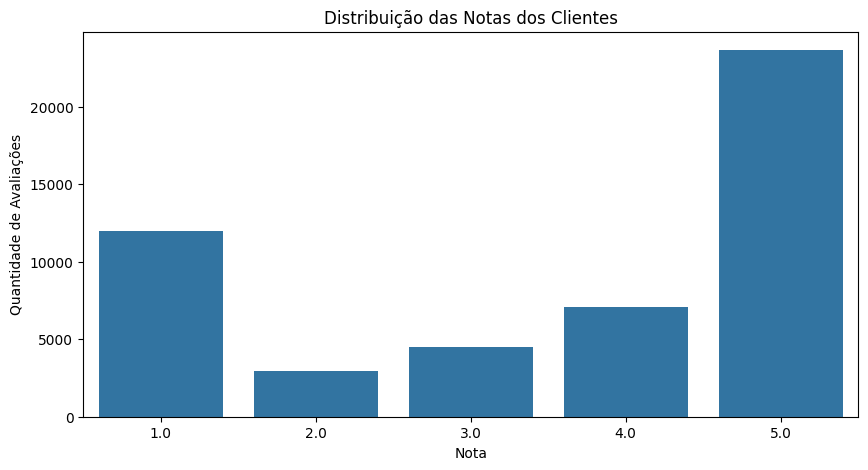

In [55]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_completo,
    x='review_score'
)

plt.title('Distribuição das Notas dos Clientes')
plt.xlabel('Nota')
plt.ylabel('Quantidade de Avaliações')
plt.show()

Observa-se que a maior parte das avaliações está concentrada na nota mais alta e mais baixa, especialmente nas avaliações de 1 e 5 estrelas. Esse comportamento sugere que os clientes tendem a registrar avaliações quando possuem experiências satisfatórias com os produtos ou serviços adquiridos, ou quando a experiência é extremamente negativa.

**Gráfico de Barras: O gráfico a seguir compara a média das pontuações de sentimento calculadas pelos três modelos utilizados:**

- VADER
- LeIA
- Transformers

O objetivo é verificar se existe concordância geral entre os algoritmos na interpretação dos comentários dos clientes.

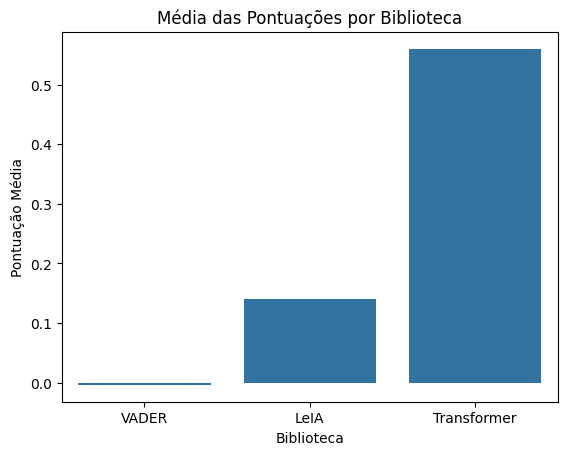

In [56]:
medias = pd.DataFrame({
    'Biblioteca': ['VADER', 'LeIA', 'Transformer'],
    'Pontuação Média': [
        df_completo['pontuacao_vader'].mean(),
        df_completo['pontuacao_leia'].mean(),
        df_completo['pontuacao_transformer'].mean()
    ]
})

sns.barplot(
    data=medias,
    x='Biblioteca',
    y='Pontuação Média'
)

plt.title('Média das Pontuações por Biblioteca')
plt.show()

Enquanto Vader e LeIA utilizam abordagens léxicas, o modelo Transformers emprega redes neurais profundas, capazes de capturar contextos mais complexos da linguagem. O que explica a diferença de pontuação média entre elas.

Observação: A Vader possui mais dificuldade para ler comentários em português ou muito longos, portanto ao não identificar o problema de um comentário ela tende a classifica-lo como neutro.

**Gráfico de Barras: Comparação dos Tipos de Sentimento**

Este gráfico apresenta a distribuição das classificações de sentimento geradas por cada biblioteca.

A análise permite verificar o comportamento dos algoritmos na identificação de comentários:

Muito Negativos
Negativos
Neutros
Positivos
Muito Positivos

In [78]:
mapa_notas = {
    1: 'Muito Negativo',
    2: 'Negativo',
    3: 'Neutro',
    4: 'Positivo',
    5: 'Muito Positivo'
}

notas_classificadas = (
    df_completo['review_score']
    .map(mapa_notas)
    .value_counts()
)

ordem = ['Muito Negativo', 'Negativo', 'Neutro', 'Positivo', 'Muito Positivo']

In [79]:
comparacao = pd.DataFrame({
    'Notas Reais': notas_classificadas,
    'VADER': df_completo['classificacao_vader'].value_counts(),
    'LeIA': df_completo['classificacao_leia'].value_counts(),
    'Transformer': df_completo['classificacao_transformer'].value_counts()
}).fillna(0)

comparacao = comparacao.reindex(ordem)

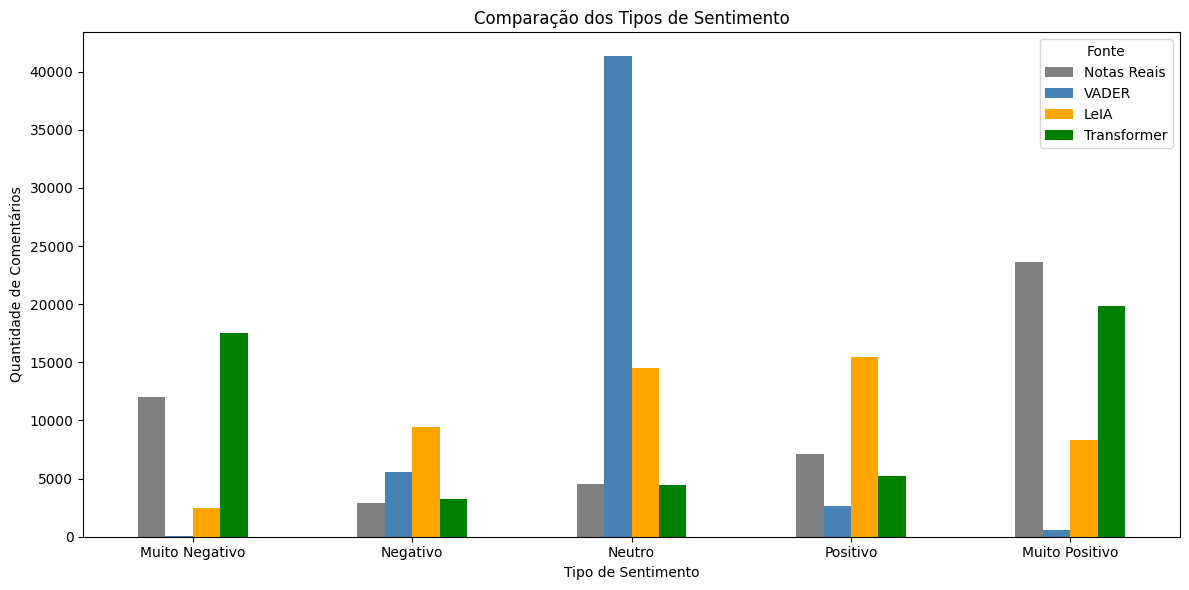

In [102]:
ax = comparacao.plot(
    kind='bar',
    figsize=(12,6),
    color=['gray', 'steelblue', 'orange', 'green']
)

plt.title('Comparação dos Tipos de Sentimento')
plt.xlabel('Tipo de Sentimento')
plt.ylabel('Quantidade de Comentários')
plt.xticks(rotation=0)
plt.legend(title='Fonte')

plt.tight_layout()
plt.show()

**Matriz de Correlação entre os Modelos**: A matriz de correlação permite analisar o grau de concordância entre as pontuações geradas pelos modelos de análise de sentimento.

Valores próximos de:

1 indicam forte correlação positiva;
0 indicam ausência de correlação;
-1 indicam correlação negativa.

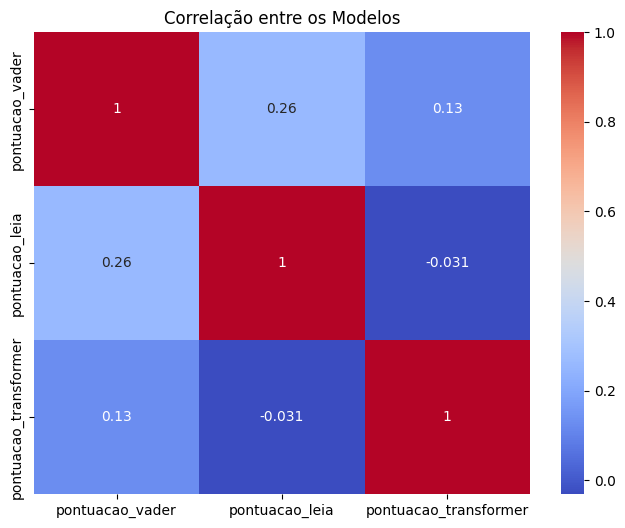

In [62]:
corr = df_completo[
    [
        'pontuacao_vader',
        'pontuacao_leia',
        'pontuacao_transformer'
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlação entre os Modelos')
plt.show()

É possível concluir que a LeIA e a Vader chegam a opiniões mais semelhantes, por conta que a leIA é uma versão aprimorada da Vader, portanto possuem a mesma espécie de "origem", enquanto a transformers é um modelo completamente diferente! Por conseguinte, seu resultado não terá concordância com as outras duas bibliotecas. 

**Gráfico de linhas: Sentimento Médio por Nota das Bibliotecas**

O gráfico apresenta a média das pontuações de sentimento das bibliotecas para cada nota atribuída pelos clientes. O objetivo é verificar se existe coerência entre a avaliação numérica e o pontuação do comentário.

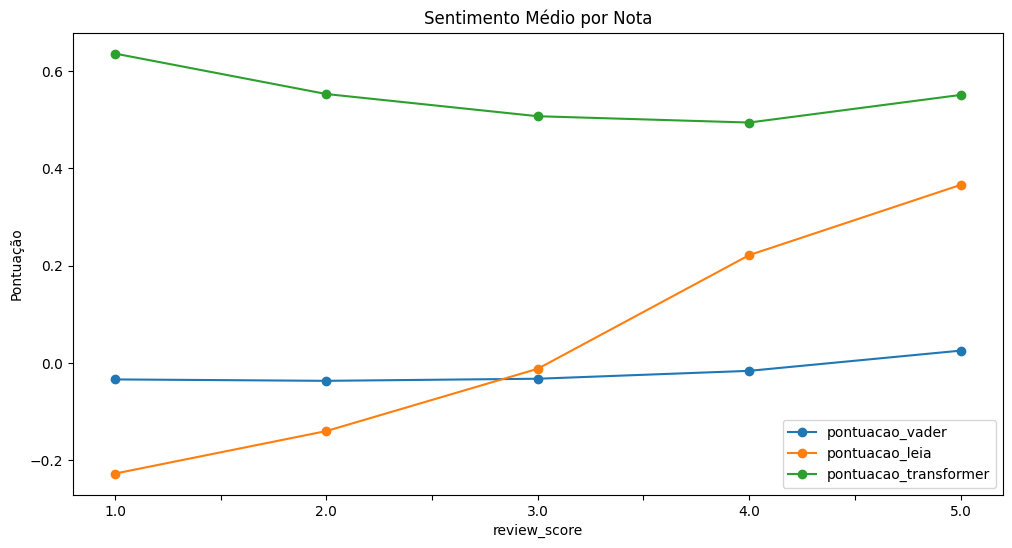

In [63]:
media_por_nota = (
    df_completo
    .groupby('review_score')
    [
        [
            'pontuacao_vader',
            'pontuacao_leia',
            'pontuacao_transformer'
        ]
    ]
    .mean()
)

media_por_nota.plot(
    marker='o',
    figsize=(12,6)
)

plt.title('Sentimento Médio por Nota')
plt.ylabel('Pontuação')
plt.show()

Espera-se que avaliações mais altas estejam associadas a sentimentos mais positivos, enquanto avaliações mais baixas estejam associadas a sentimentos negativos.

Reforçando a consistência dos dados. Eventuais desvios podem indicar situações em que o comentário e a nota não refletem a mesma percepção do cliente. Algo perceptível na biblioteca LeIA, quanto maior a nota, melhor é o sentimento atríbuido a ela.

**Tabela: Identificação de Avaliações Incoerentes**

Nesta etapa foram identificadas possíveis inconsistências entre a nota atribuída e o sentimento detectado no comentário.

Foram considerados dois cenários:

Nota máxima acompanhada de comentário negativo;
Nota mínima acompanhada de comentário positivo.

In [64]:
incoerentes = df_completo[
    (df_completo['review_score'] == 5)
    &
    (df_completo['pontuacao_transformer'] < 0.3)
]

In [65]:
incoerentes2 = df_completo[
    (df_completo['review_score'] == 1)
    &
    (df_completo['pontuacao_transformer'] > 0.7)
]

In [66]:
pd.DataFrame({
    'Tipo': [
        'Nota alta + comentário negativo',
        'Nota baixa + comentário positivo'
    ],
    'Quantidade': [
        len(incoerentes),
        len(incoerentes2)
    ]
})

,Tipo,Quantidade
0,Nota alta + comentário negativo,1867
1,Nota baixa + comentário positivo,4956


Esses casos representam situações potencialmente incoerentes, nas quais o texto do comentário não corresponde à avaliação numérica registrada. A identificação dessas ocorrências pode auxiliar empresas na revisão de métricas de satisfação, além de revelar possíveis erros de preenchimento ou ambiguidades na comunicação dos clientes.

**Nuvem de Palavras - Avaliações Positivas**

A nuvem de palavras apresenta os termos mais frequentes nos comentários associados às avaliações máximas. Quanto maior o tamanho da palavra, maior sua frequência nos comentários.

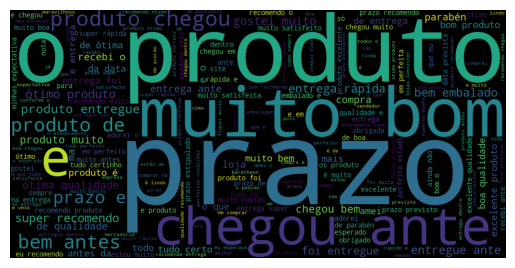

In [67]:
texto = ' '.join(
    df_completo[
        df_completo['review_score'] == 5
    ]['review_comment_message']
)

wordcloud = WordCloud(
    width=1000,
    height=500
).generate(texto)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

A análise permite identificar rapidamente quais aspectos são mais valorizados pelos clientes. Termos relacionados à entrega, qualidade do produto e prazo costumam aparecer com maior frequência em avaliações positivas.

**Nuvem de Palavras - Avaliações Negativas**

A nuvem de palavras apresenta os termos mais frequentes nos comentários associados às avaliações mais baixas. Quanto maior o tamanho da palavra, maior sua frequência nos comentários.

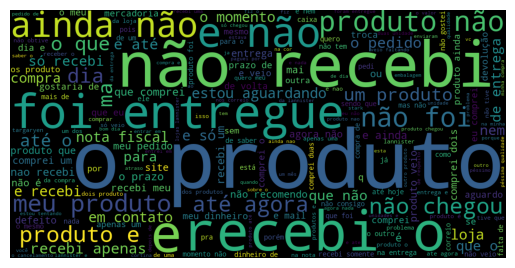

In [68]:
texto = ' '.join(
    df_completo[
        df_completo['review_score'] == 1
    ]['review_comment_message']
)

wordcloud = WordCloud(
    width=1000,
    height=500
).generate(texto)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

A identificação dessas palavras permite compreender os principais motivos de reclamação. Problemas relacionados à entrega, defeitos no produto, divergência de expectativa e atendimento geralmente aparecem com maior frequência em avaliações negativas.

**Palavras Mais Frequentes em Comentários Positivos**

Além da nuvem de palavras, foi realizada uma análise quantitativa dos termos mais frequentes encontrados nos comentários positivos.

In [69]:
texto = ' '.join(
    df_completo[
        df_completo['review_score'] == 5
    ]['review_comment_message']
)

palavras = texto.split()

top = Counter(palavras).most_common(15)

pd.DataFrame(
    top,
    columns=['Palavra','Frequência']
)

,Palavra,Frequência
0,produto,7818
1,e,7107
2,do,6860
3,o,6090
4,muito,5905
5,antes,5015
6,a,4383
7,de,4352
8,prazo,3673
9,entrega,3626


Text(0, 0.5, 'Palavras')

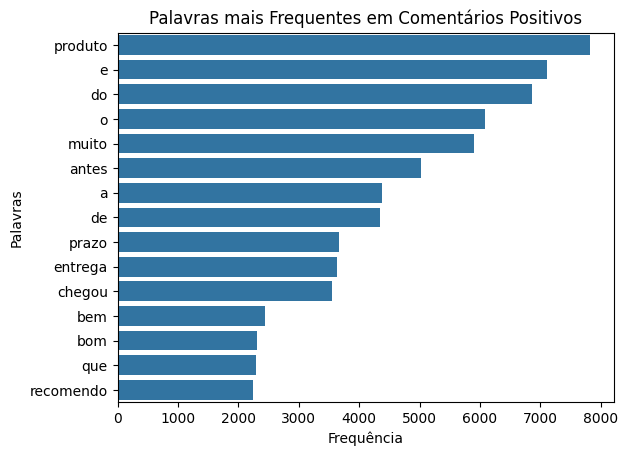

In [70]:
sns.barplot(
    x=[x[1] for x in top],
    y=[x[0] for x in top]
)

plt.title('Palavras mais Frequentes em Comentários Positivos')
plt.xlabel('Frequência')
plt.ylabel('Palavras')

Os resultados ajudam a identificar quais características do serviço ou produto são mais mencionadas pelos clientes satisfeitos. Essa informação pode servir como apoio para estratégias de marketing e melhoria contínua da experiência do consumidor.

**Gráfico de Barras: 10 Categorias com Maior Sentimento Médio**

O gráfico apresenta as categorias de produtos que obtiveram as maiores médias de sentimento segundo o modelo Transformers.

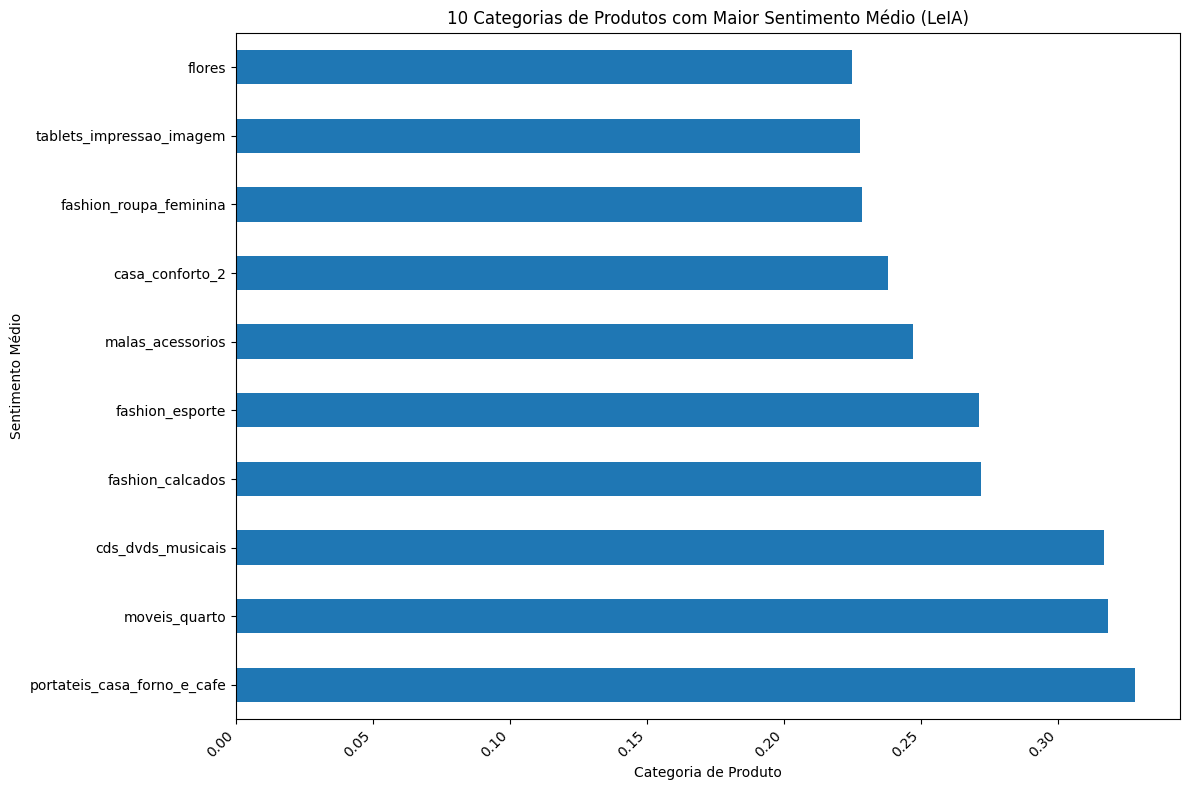

In [98]:
categoria = (
    df_completo
    .groupby('product_category_name')
    ['pontuacao_leia']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

categoria.plot(
    kind='barh',
    figsize=(12,8)
)

plt.title('10 Categorias de Produtos com Maior Sentimento Médio (LeIA)')
plt.xlabel('Categoria de Produto')
plt.ylabel('Sentimento Médio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Categorias com maiores médias indicam maior satisfação dos consumidores. Essa análise pode auxiliar gestores na identificação dos segmentos mais bem avaliados, permitindo direcionar investimentos e estratégias comerciais para produtos que apresentam melhor percepção junto aos clientes.

**Gráfico de Barras: 10 Categorias com Menor Sentimento Médio**

O objetivo é identificar os segmentos que apresentam maior nível de insatisfação por parte dos consumidores.

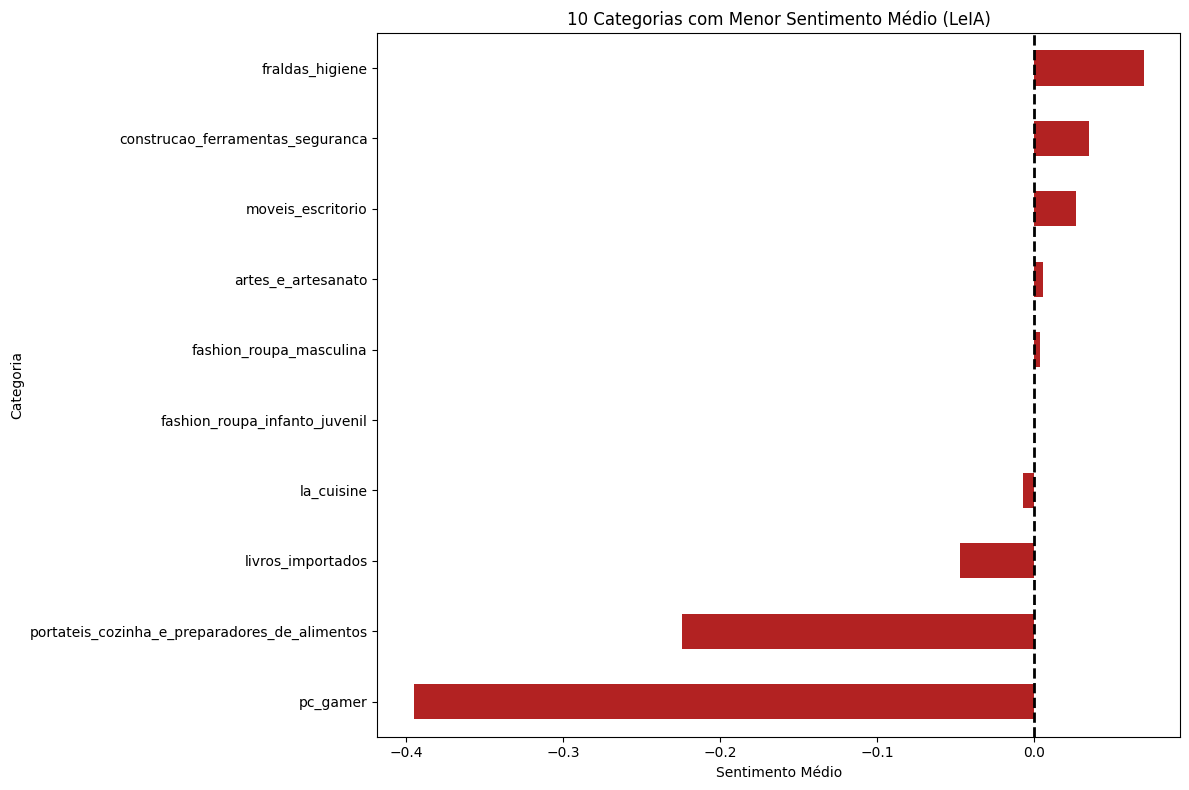

In [100]:
categoria_negativa = (
    df_completo
    .groupby('product_category_name')['pontuacao_leia']
    .mean()
    .sort_values(ascending=True)
    .head(10)
)

categoria_negativa.plot(
    kind='barh',
    figsize=(12,8),
    color='firebrick'
)

plt.axvline(
    x=0,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Neutro (0)'
)

plt.title('10 Categorias com Menor Sentimento Médio (LeIA)')
plt.xlabel('Sentimento Médio')
plt.ylabel('Categoria')

plt.tight_layout()
plt.show()

As categorias com menor sentimento médio concentram comentários mais negativos, indicando possíveis problemas relacionados à qualidade dos produtos, prazo de entrega, expectativa do cliente ou atendimento. A identificação desses grupos permite direcionar ações corretivas e estratégias de melhoria contínua, contribuindo para o aumento da satisfação dos consumidores e para a redução de avaliações negativas.

# **Conclusão**

O presente projeto teve como objetivo analisar a relação entre as avaliações numéricas e os comentários textuais realizados pelos clientes de um marketplace, utilizando técnicas de Análise Exploratória de Dados (EDA).

A partir da integração das diferentes tabelas disponibilizadas pela AWS e pelo SENAI Suíço-Brasileiro, foi possível construir uma base consolidada contendo informações de pedidos, produtos, pagamentos, vendedores, clientes e avaliações. Após o processo de limpeza, tratamento e padronização dos dados, foram aplicados três modelos distintos de análise de sentimento: VADER, LeIA e Transformers.

Os resultados demonstraram que existe uma forte relação entre as notas atribuídas pelos clientes e o sentimento identificado nos comentários. Em geral, avaliações com notas elevadas apresentaram sentimentos positivos, enquanto avaliações com notas baixas foram associadas a sentimentos negativos. Além disso, observou-se elevada disconcordância entre os modelos utilizados.

Também foram identificados casos de incoerência entre a nota e o conteúdo textual do comentário, evidenciando situações em que a avaliação numérica não representa completamente a percepção expressa pelo cliente. Esse tipo de ocorrência demonstra a importância da análise textual como complemento às métricas tradicionais de satisfação. Sendo relevante destacar que a quantidade de avaliações que condizem o oposto do score atribuído correspondem a aproximadamente 10% das avaliações do banco de dados.  

As análises de frequência de palavras e as nuvens de palavras permitiram identificar os principais fatores associados à satisfação e à insatisfação dos consumidores, oferecendo informações relevantes para a tomada de decisão empresarial. Da mesma forma, a análise por categoria de produto possibilitou identificar segmentos com melhor percepção por parte dos clientes.

Dessa forma, conclui-se que a utilização de técnicas de Ciência de Dados fornece uma visão mais completa sobre a experiência dos consumidores, permitindo compreender não apenas as notas atribuídas, mas também os sentimentos expressos nos comentários. Os resultados obtidos demonstram o potencial dessas ferramentas para apoiar estratégias de melhoria contínua, gestão da qualidade e aumento da satisfação dos clientes em ambientes de *marketplace*, ou áreas que necessitem de um score deixado pelo cliente!
